In [61]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, precision_recall_curve, auc, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit
import optuna
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import joblib







In [62]:
DATA_DIR = '../data/raw'
dfs = {}
for file in os.listdir(DATA_DIR):
    if file.endswith('.csv'):
        table_name = file.replace('olist_', '').replace('_dataset.csv', '')
        dfs[table_name] = pd.read_csv(os.path.join(DATA_DIR, file))
        print(f'Загружена таблица: {table_name}, размер: {dfs[table_name].shape}')

Загружена таблица: sellers, размер: (3095, 4)
Загружена таблица: product_category_name_translation.csv, размер: (71, 2)
Загружена таблица: orders, размер: (99441, 8)
Загружена таблица: order_items, размер: (112650, 7)
Загружена таблица: customers, размер: (99441, 5)
Загружена таблица: geolocation, размер: (1000163, 5)
Загружена таблица: order_payments, размер: (103886, 5)
Загружена таблица: order_reviews, размер: (99224, 7)
Загружена таблица: products, размер: (32951, 9)


In [63]:
orders = dfs['orders'].copy()
customers = dfs['customers'].copy()
payments = dfs['order_payments'].copy()
reviews = dfs['order_reviews'].copy()
sellers = dfs['sellers'].copy()
order_items = dfs['order_items'].copy()
product = dfs['products'].copy()

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

In [64]:
orders_payments_agg = payments.groupby('order_id').agg(
    total_payment = ('payment_value', 'sum'),
    max_installments = ('payment_installments', 'max')).reset_index()

order_reviews_agg = reviews.groupby('order_id').agg(
    review_score = ('review_score', 'mean')).reset_index()

order_items_agg = order_items.groupby('order_id').agg(
    items_count = ('product_id', 'count'),
    total_freight_value = ('freight_value', 'sum')).reset_index()

**payments**

**reviews**

**order_items**

In [65]:
print(orders['order_purchase_timestamp'].max() - pd.Timedelta(days=90))

2018-07-19 17:30:18


In [66]:
cutoff_date = pd.to_datetime('2018-05-01')
churn_days = 90

obs_orders = orders[orders['order_purchase_timestamp'] < cutoff_date]

pred_end_date = cutoff_date + pd.Timedelta(days=churn_days)

pred_orders = orders[(orders['order_purchase_timestamp'] >= cutoff_date) & (orders['order_purchase_timestamp'] < pred_end_date)].copy()

print(f"Дата отсечки: {cutoff_date}")
print(f"Размер истории заказов (obs_orders): {obs_orders.shape}")
print(f"Размер окна для таргета (pred_orders): {pred_orders.shape}")


Дата отсечки: 2018-05-01 00:00:00
Размер истории заказов (obs_orders): (73577, 8)
Размер окна для таргета (pred_orders): (18722, 8)


In [67]:
obs_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00


In [68]:
orders_payments_agg.head()

,order_id,total_payment,max_installments
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2
1,00018f77f2f0320c557190d7a144bdd3,259.83,3
2,000229ec398224ef6ca0657da4fc703e,216.87,5
3,00024acbcdf0a6daa1e931b038114c75,25.78,2
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3


In [69]:
df_history = obs_orders.merge(customers, on='customer_id', how='inner')
df_history = df_history.merge(orders_payments_agg, on='order_id', how='left')
df_history = df_history.merge(order_reviews_agg, on='order_id', how='left')
df_history = df_history.merge(order_items_agg, on='order_id', how='left')

df_history.shape

(73577, 17)

In [70]:
df_history.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  86
order_delivered_carrier_date     1482
order_delivered_customer_date    2453
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
total_payment                       1
max_installments                    1
review_score                      635
items_count                       650
total_freight_value               650
dtype: int64

In [71]:
df_history.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                        object
order_delivered_carrier_date             object
order_delivered_customer_date            object
order_estimated_delivery_date            object
customer_unique_id                       object
customer_zip_code_prefix                  int64
customer_city                            object
customer_state                           object
total_payment                           float64
max_installments                        float64
review_score                            float64
items_count                             float64
total_freight_value                     float64
dtype: object

In [72]:
df_history['order_delivered_carrier_date'] = pd.to_datetime(df_history['order_delivered_carrier_date'])
df_history['order_delivered_customer_date'] = pd.to_datetime(df_history['order_delivered_customer_date'])
df_history['order_estimated_delivery_date'] = pd.to_datetime(df_history['order_estimated_delivery_date'])
df_history['order_approved_at'] = pd.to_datetime(df_history['order_approved_at'])

df_history.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
customer_unique_id                       object
customer_zip_code_prefix                  int64
customer_city                            object
customer_state                           object
total_payment                           float64
max_installments                        float64
review_score                            float64
items_count                             float64
total_freight_value                     float64
dtype: object

In [73]:
df_history['days_since_order'] = (cutoff_date - df_history['order_purchase_timestamp']).dt.days
df_history['delivery_delay'] = (df_history['order_delivered_customer_date'] - df_history['order_estimated_delivery_date']).dt.days.clip(lower=0)
df_history['is_canceled'] = df_history['order_status'].isin(['canceled', 'unavailable']).astype(int)

print(df_history['order_status'].unique())
df_history.head()

['delivered' 'invoiced' 'processing' 'shipped' 'unavailable' 'canceled'
 'created' 'approved']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_payment,max_installments,review_score,items_count,total_freight_value,days_since_order,delivery_delay,is_canceled
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,1.0,4.0,1.0,8.72,210,0.0,0
1,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,1.0,5.0,1.0,27.20,163,0.0,0
2,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,1.0,5.0,1.0,8.72,76,0.0,0
3,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR,175.26,6.0,4.0,1.0,27.36,295,0.0,0
4,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09,36edbb3fb164b1f16485364b6fb04c73,98900,santa rosa,RS,65.95,1.0,2.0,1.0,16.05,384,NaN,0


In [74]:
feature = df_history.groupby('customer_unique_id').agg(
    recency_days = ('days_since_order', 'min'),
    tenure_days = ('days_since_order', 'max'),
    total_orders = ('order_id', 'nunique'),
    total_spent = ('total_payment', 'sum'),
    max_installments = ('max_installments', 'max'),
    avg_review_score = ('review_score', 'mean'),
    min_review_score = ('review_score', 'min'),
    avg_delivery_delay = ('delivery_delay', 'mean'),
    max_delivery_delay = ('delivery_delay', 'max'),
    cancellation_rate = ('is_canceled', 'mean')
).reset_index()

feature['avg_spent'] = feature['total_spent'] / feature['total_orders']
feature['installment_burden'] = feature['max_installments'] / feature['avg_spent']
feature['purchase_intensity'] = feature['total_orders'] / (feature['tenure_days'].clip(lower=1) / 30)

feature


,customer_unique_id,recency_days,tenure_days,total_orders,total_spent,max_installments,avg_review_score,min_review_score,avg_delivery_delay,max_delivery_delay,cancellation_rate,avg_spent,installment_burden,purchase_intensity
0,0000f46a3911fa3c0805444483337064,416,416,1,86.22,8.0,3.0,3.0,0.0,0.0,0.0,86.22,0.092786,0.072115
1,0000f6ccb0745a6a4b88665a16c9f078,200,200,1,43.62,4.0,4.0,4.0,0.0,0.0,0.0,43.62,0.091701,0.150000
2,0004aac84e0df4da2b147fca70cf8255,167,167,1,196.89,6.0,5.0,5.0,0.0,0.0,0.0,196.89,0.030474,0.179641
3,0004bd2a26a76fe21f786e4fbd80607f,25,25,1,166.98,8.0,4.0,4.0,0.0,0.0,0.0,166.98,0.047910,1.200000
4,00050ab1314c0e55a6ca13cf7181fecf,10,10,1,35.38,1.0,4.0,4.0,0.0,0.0,0.0,35.38,0.028265,3.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71181,fffcc512b7dfecaffd80f13614af1d16,19,19,1,710.70,3.0,1.0,1.0,NaN,NaN,0.0,710.70,0.004221,1.578947
71182,fffcf5a5ff07b0908bd4e2dbc735a684,326,326,1,2067.42,10.0,5.0,5.0,0.0,0.0,0.0,2067.42,0.004837,0.092025
71183,fffea47cd6d3cc0a88bd621562a9d061,141,141,1,84.58,1.0,4.0,4.0,0.0,0.0,0.0,84.58,0.011823,0.212766
71184,ffff371b4d645b6ecea244b27531430a,447,447,1,112.46,1.0,5.0,5.0,0.0,0.0,0.0,112.46,0.008892,0.067114


In [75]:
feature.isna().sum()

customer_unique_id       0
recency_days             0
tenure_days              0
total_orders             0
total_spent              0
max_installments         1
avg_review_score       593
min_review_score       593
avg_delivery_delay    2301
max_delivery_delay    2301
cancellation_rate        0
avg_spent                0
installment_burden       1
purchase_intensity       0
dtype: int64

In [76]:
feature['avg_review_score'] = feature['avg_review_score'].fillna(feature['avg_review_score'].median())
feature['min_review_score'] = feature['min_review_score'].fillna(feature['min_review_score'].median())
feature['avg_delivery_delay'] = feature['avg_delivery_delay'].fillna(feature['avg_delivery_delay'].median())
feature['max_delivery_delay'] = feature['max_delivery_delay'].fillna(feature['max_delivery_delay'].median())
feature['max_installments'] = feature['max_installments'].fillna(1)
feature['installment_burden'] = feature['max_installments'] / feature['avg_spent']

feature.isna().sum()

customer_unique_id    0
recency_days          0
tenure_days           0
total_orders          0
total_spent           0
max_installments      0
avg_review_score      0
min_review_score      0
avg_delivery_delay    0
max_delivery_delay    0
cancellation_rate     0
avg_spent             0
installment_burden    0
purchase_intensity    0
dtype: int64

In [77]:
pred_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
12,82566a660a982b15fb86e904c8d32918,d3e3b74c766bc6214e0c830b17ee2341,delivered,2018-06-07 10:06:19,2018-06-09 03:13:12,2018-06-11 13:29:00,2018-06-19 12:05:52,2018-07-18 00:00:00
13,5ff96c15d0b717ac6ad1f3d77225a350,19402a48fe860416adf93348aba37740,delivered,2018-07-25 17:44:10,2018-07-25 17:55:14,2018-07-26 13:16:00,2018-07-30 15:52:25,2018-08-08 00:00:00
15,dcb36b511fcac050b97cd5c05de84dc3,3b6828a50ffe546942b7a473d70ac0fc,delivered,2018-06-07 19:03:12,2018-06-12 23:31:02,2018-06-11 14:54:00,2018-06-21 15:34:32,2018-07-04 00:00:00
26,acce194856392f074dbf9dada14d8d82,7e20bf5ca92da68200643bda76c504c6,delivered,2018-06-04 00:00:13,2018-06-05 00:35:10,2018-06-05 13:24:00,2018-06-16 15:20:55,2018-07-18 00:00:00


In [78]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [79]:
pred_customers = pred_orders.merge(customers, on='customer_id', how='inner')
retained_users = set(pred_customers['customer_unique_id'].unique())

In [80]:
feature['churn'] = (~feature['customer_unique_id'].isin(retained_users)).astype(int)
feature['churn'].value_counts()

churn
1    70740
0      446
Name: count, dtype: int64

In [81]:
def build_features_for_date(orders, customers, orders_payments_agg, order_reviews_agg, order_items_agg, cutoff_date, churn_days = 90):
    
    obs_orders = orders[orders['order_purchase_timestamp'] < cutoff_date]
    pred_end_date = cutoff_date + pd.Timedelta(days=churn_days)
    pred_orders = orders[(orders['order_purchase_timestamp'] >= cutoff_date) & (orders['order_purchase_timestamp'] < pred_end_date)].copy()
    
    df_history = obs_orders.merge(customers, on='customer_id', how='inner')
    df_history = df_history.merge(orders_payments_agg, on='order_id', how='left')
    df_history = df_history.merge(order_reviews_agg, on='order_id', how='left')
    df_history = df_history.merge(order_items_agg, on='order_id', how='left')
    
    df_history['order_delivered_carrier_date'] = pd.to_datetime(df_history['order_delivered_carrier_date'])
    df_history['order_delivered_customer_date'] = pd.to_datetime(df_history['order_delivered_customer_date'])
    df_history['order_estimated_delivery_date'] = pd.to_datetime(df_history['order_estimated_delivery_date'])
    
    df_history['days_since_order'] = (cutoff_date - df_history['order_purchase_timestamp']).dt.days
    df_history['delivery_delay'] = (df_history['order_delivered_customer_date'] - df_history['order_estimated_delivery_date']).dt.days.clip(lower=0)
    df_history['is_canceled'] = df_history['order_status'].isin(['canceled', 'unavailable']).astype(int)
    
    feature = df_history.groupby('customer_unique_id').agg(
        recency_days = ('days_since_order', 'min'),
        tenure_days = ('days_since_order', 'max'),
        total_orders = ('order_id', 'nunique'),
        total_spent = ('total_payment', 'sum'),
        max_installments = ('max_installments', 'max'),
        avg_review_score = ('review_score', 'mean'),
        min_review_score = ('review_score', 'min'),
        avg_delivery_delay = ('delivery_delay', 'mean'),
        max_delivery_delay = ('delivery_delay', 'max'),
        cancellation_rate = ('is_canceled', 'mean'),
        customer_state = ('customer_state', 'last'),
        customer_city = ('customer_city', 'last')
    ).reset_index()

    feature['avg_spent'] = feature['total_spent'] / feature['total_orders']
    feature['purchase_intensity'] = feature['total_orders'] / (feature['tenure_days'].clip(lower=1) / 30)
    
    lag_date = cutoff_date - pd.Timedelta(days=90)
    df_history_90d = df_history[df_history['order_purchase_timestamp'] >= lag_date]
    
    lag_features = df_history_90d.groupby('customer_unique_id').agg(
        lag_90d_orders=('order_id', 'nunique'),
        lag_90d_spent=('total_payment', 'sum')
    ).reset_index()
    
    feature = feature.merge(lag_features, on='customer_unique_id', how='left')
    feature['lag_90d_orders'] = feature['lag_90d_orders'].fillna(0)
    feature['lag_90d_spent'] = feature['lag_90d_spent'].fillna(0)
    feature['recent_spend_ratio'] = feature['lag_90d_spent'] / feature['total_spent'].clip(lower=1)
    
    feature['avg_review_score'] = feature['avg_review_score'].fillna(feature['avg_review_score'].median())
    feature['min_review_score'] = feature['min_review_score'].fillna(feature['min_review_score'].median())
    feature['avg_delivery_delay'] = feature['avg_delivery_delay'].fillna(feature['avg_delivery_delay'].median())
    feature['max_delivery_delay'] = feature['max_delivery_delay'].fillna(feature['max_delivery_delay'].median())
    feature['max_installments'] = feature['max_installments'].fillna(1)
    feature['installment_burden'] = feature['total_spent'] / feature['max_installments']
    
    pred_customers = pred_orders.merge(customers, on='customer_id', how='inner')
    retained_users = set(pred_customers['customer_unique_id'].unique())
    feature['churn'] = (~feature['customer_unique_id'].isin(retained_users)).astype(int)
    
    return feature

In [82]:
cutoff_dates = pd.date_range(start='2017-07-01', end='2018-07-01', freq='MS')
all_features = []

for date in cutoff_dates:
    print(f'Генерация фичей для даты: {date.date()}')
    df_slice = build_features_for_date(
        orders=orders,
        customers=customers,
        orders_payments_agg=orders_payments_agg,
        order_reviews_agg=order_reviews_agg,
        order_items_agg=order_items_agg,
        cutoff_date=date, 
        churn_days=90
    )
    df_slice['snapshot_date'] = date
    all_features.append(df_slice)
    
    
df_master = pd.concat(all_features, ignore_index=True)
print(f'\nИтоговый размер мастер-датасета: {df_master.shape}')
print('\nБаланс классов в мастер-датасете:')
print(df_master['churn'].value_counts())


Генерация фичей для даты: 2017-07-01
Генерация фичей для даты: 2017-08-01
Генерация фичей для даты: 2017-09-01
Генерация фичей для даты: 2017-10-01
Генерация фичей для даты: 2017-11-01
Генерация фичей для даты: 2017-12-01
Генерация фичей для даты: 2018-01-01
Генерация фичей для даты: 2018-02-01
Генерация фичей для даты: 2018-03-01
Генерация фичей для даты: 2018-04-01
Генерация фичей для даты: 2018-05-01
Генерация фичей для даты: 2018-06-01
Генерация фичей для даты: 2018-07-01

Итоговый размер мастер-датасета: (602050, 21)

Баланс классов в мастер-датасете:
churn
1    598020
0      4030
Name: count, dtype: int64


In [83]:
df_master = df_master.sort_values('snapshot_date')

In [84]:
cat_cols = ['customer_state', 'customer_city']
for col in cat_cols:
    df_master[col] = df_master[col].astype('category')

train_df = df_master[df_master['snapshot_date'] < '2018-06-01']
test_df = df_master[df_master['snapshot_date'] >= '2018-06-01']

drop_cols = ['customer_unique_id', 'snapshot_date', 'churn']
X_train = train_df.drop(columns=drop_cols)
y_train = train_df['churn']
X_test = test_df.drop(columns=drop_cols)
y_test = test_df['churn']

print(f'Размер Train: {train_df.shape}')
print(f'Размер Test: {test_df.shape}')

Размер Train: (440494, 21)
Размер Test: (161556, 21)


In [85]:
train_df = df_master[df_master['snapshot_date'] < '2018-06-01']
test_df = df_master[df_master['snapshot_date'] >= '2018-06-01']

print(f'Размер Train: {train_df.shape}')
print(f'Размер Test: {test_df.shape}')

Размер Train: (440494, 21)
Размер Test: (161556, 21)


In [86]:
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=10,
    auto_class_weights='Balanced',
    eval_metric='AUC',
    random_seed=42,
    verbose=50
)

model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    cat_features=cat_cols,
    early_stopping_rounds=50
)

0:	test: 0.6557940	best: 0.6557940 (0)	total: 89.7ms	remaining: 44.8s
50:	test: 0.7326328	best: 0.7331360 (49)	total: 3.78s	remaining: 33.3s
100:	test: 0.7471534	best: 0.7471534 (100)	total: 7.15s	remaining: 28.3s
150:	test: 0.7510512	best: 0.7513896 (148)	total: 10.3s	remaining: 23.8s
200:	test: 0.7581466	best: 0.7581466 (200)	total: 13.4s	remaining: 19.9s
250:	test: 0.7615127	best: 0.7615210 (242)	total: 16.7s	remaining: 16.5s
300:	test: 0.7625534	best: 0.7647626 (269)	total: 20.4s	remaining: 13.5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7647626358
bestIteration = 269

Shrink model to first 270 iterations.


CatBoostClassifier(auto_class_weights='Balanced', depth=10, eval_metric='AUC', iterations=500, learning_rate=0.05, random_seed=42, verbose=50)

In [87]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {roc_auc:.4f}")

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)
print(f"PR-AUC: {pr_auc:.4f}\n")

print("Отчет классификации:")
print(classification_report(y_test, y_pred))

ROC-AUC: 0.7648
PR-AUC: 0.9981

Отчет классификации:
              precision    recall  f1-score   support

           0       0.02      0.57      0.03       738
           1       1.00      0.84      0.91    160818

    accuracy                           0.84    161556
   macro avg       0.51      0.70      0.47    161556
weighted avg       0.99      0.84      0.91    161556



In [88]:
train_val_df = df_master[df_master['snapshot_date'] < '2018-06-01'].reset_index(drop=True)
X_train_val = train_val_df.drop(columns=drop_cols)
y_train_val = train_val_df['churn']

def objective(trial):
    classifier_name = trial.suggest_categorical("classifier", ["CatBoost", "LightGBM"])
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_train_val):
        X_tr, X_va = X_train_val.iloc[train_idx], X_train_val.iloc[val_idx]
        y_tr, y_va = y_train_val.iloc[train_idx], y_train_val.iloc[val_idx]
        
        if classifier_name == "CatBoost":
            params = {
                'iterations': trial.suggest_int('cb_iterations', 500, 1500),
                'learning_rate': trial.suggest_float('cb_lr', 0.01, 0.1, log=True),
                'depth': trial.suggest_int('cb_depth', 4, 10), 
                'l2_leaf_reg': trial.suggest_float('cb_l2', 1.0, 30.0), 
                'auto_class_weights': 'Balanced',
                'eval_metric': 'AUC',
                'random_seed': 42,
                'verbose': False
            }
            model = CatBoostClassifier(**params)
            model.fit(X_tr, y_tr, eval_set=(X_va, y_va), cat_features=cat_cols, early_stopping_rounds=50, verbose=False)
            preds = model.predict_proba(X_va)[:, 1]
            
        else:
            params = {
                'n_estimators': trial.suggest_int('lgb_n_estimators', 500, 1500),
                'learning_rate': trial.suggest_float('lgb_lr', 0.01, 0.1, log=True),
                'max_depth': trial.suggest_int('lgb_max_depth', 4, 10),
                'num_leaves': trial.suggest_int('lgb_num_leaves', 15, 100),
                'min_child_samples': trial.suggest_int('lgb_min_child', 10, 50),
                'class_weight': 'balanced',
                'random_state': 42,
                'n_jobs': -1,
                'verbose': -1
            }
            model = LGBMClassifier(**params)
            model.fit(X_tr, y_tr, categorical_feature=cat_cols)
            preds = model.predict_proba(X_va)[:, 1]
            
        score = roc_auc_score(y_va, preds)
        cv_scores.append(score)
        
    return np.mean(cv_scores)

study = optuna.create_study(direction='maximize', study_name="CatBoost_vs_LightGBM_TSCV")
study.optimize(objective, n_trials=100)

[I 2026-07-23 20:14:25,847] A new study created in memory with name: CatBoost_vs_LightGBM_TSCV
[I 2026-07-23 20:15:58,697] Trial 0 finished with value: 0.7432529124113139 and parameters: {'classifier': 'CatBoost', 'cb_iterations': 738, 'cb_lr': 0.016646345485385756, 'cb_depth': 7, 'cb_l2': 28.898865898881365}. Best is trial 0 with value: 0.7432529124113139.
[I 2026-07-23 20:16:58,740] Trial 1 finished with value: 0.7519277296700713 and parameters: {'classifier': 'CatBoost', 'cb_iterations': 826, 'cb_lr': 0.07975935059202746, 'cb_depth': 10, 'cb_l2': 20.592430504471693}. Best is trial 1 with value: 0.7519277296700713.
[I 2026-07-23 20:17:35,945] Trial 2 finished with value: 0.7597262610613555 and parameters: {'classifier': 'LightGBM', 'lgb_n_estimators': 729, 'lgb_lr': 0.040378992367486134, 'lgb_max_depth': 10, 'lgb_num_leaves': 47, 'lgb_min_child': 44}. Best is trial 2 with value: 0.7597262610613555.
[I 2026-07-23 20:18:20,116] Trial 3 finished with value: 0.7434377689566647 and parame

In [92]:
def calculate_profit(y_true, y_proba, threshold, reward=1500, penalty=200):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    return (tp * reward) - (fp * penalty)

In [109]:
best_params = study.best_params.copy()
winning_model = best_params.pop('classifier')

if winning_model == 'LightGBM':
    final_params = {k.replace('lgb_', ''): v for k, v in best_params.items()}
    final_params.update({'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1, 'verbose': -1})
    final_model = LGBMClassifier(**final_params)
    final_model.fit(X_train, y_train, categorical_feature=cat_cols)
    joblib.dump(final_model, 'churn_model.pkl')
else:
    final_params = {k.replace('cb_', ''): v for k, v in best_params.items()}
    final_params.update({'auto_class_weights': 'Balanced', 'eval_metric': 'AUC', 'random_seed': 42, 'thread_count': -1, 'verbose': False})
    final_model = CatBoostClassifier(**final_params)
    final_model.fit(X_train, y_train, cat_features=cat_cols)
    final_model.save_model('churn_model.cbm')

final_preds_proba = final_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, final_preds_proba)

precision, recall, _ = precision_recall_curve(y_test, final_preds_proba)
test_pr_auc = auc(recall, precision)

print(f"Победитель: {winning_model}")
print(f"Финальный ROC-AUC на тесте: {test_auc:.4f}")
print(f"Финальный PR-AUC на тесте:  {test_pr_auc:.4f}")



Победитель: LightGBM
Финальный ROC-AUC на тесте: 0.7719
Финальный PR-AUC на тесте:  0.9981


Оптимальный порог вероятности: 0.0100
Максимальная расчетная прибыль кампании: 241,075,700 руб.


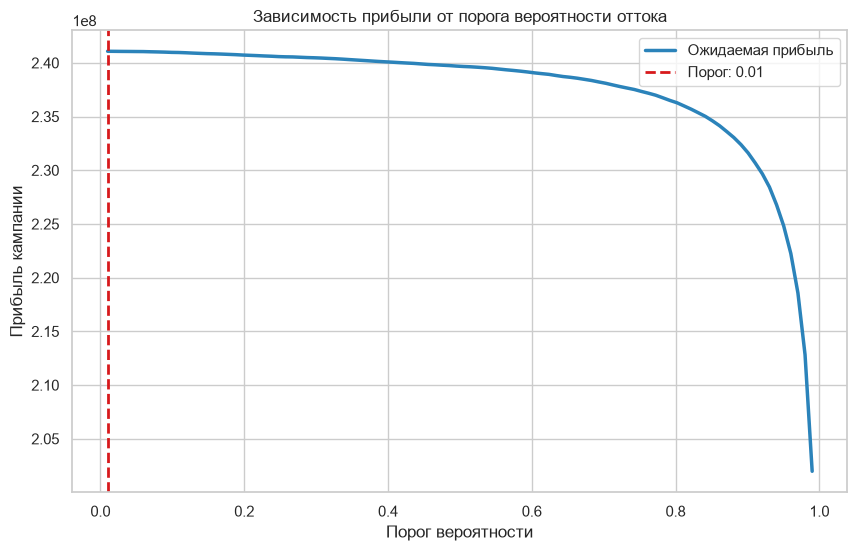

In [103]:
thresholds = np.linspace(0.01, 0.99, 100)
profits = []

for t in thresholds:
    profit = calculate_profit(y_test, final_preds_proba, threshold=t)
    profits.append(profit)

best_idx = np.argmax(profits)
best_threshold = thresholds[best_idx]
max_profit = profits[best_idx]


print(f"Оптимальный порог вероятности: {best_threshold:.4f}")
print(f"Максимальная расчетная прибыль кампании: {max_profit:,.0f} руб.")


sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.lineplot(x=thresholds, y=profits, color='#2b83ba', linewidth=2.5, label='Ожидаемая прибыль')
plt.axvline(best_threshold, color='#d7191c', linestyle='--', linewidth=2, label=f'Порог: {best_threshold:.2f}')

plt.title('Зависимость прибыли от порога вероятности оттока')
plt.xlabel('Порог вероятности')
plt.ylabel('Прибыль кампании')
plt.legend()
plt.show()

/Users/valentinzavgorodnii/Data Analyst/Zavgorodnii-Valentin/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


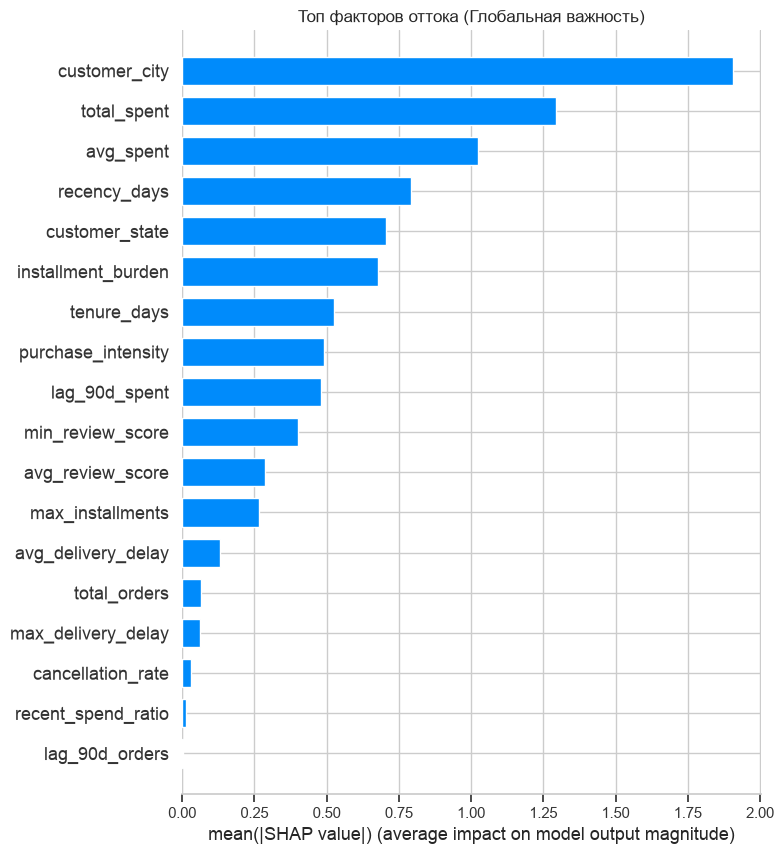

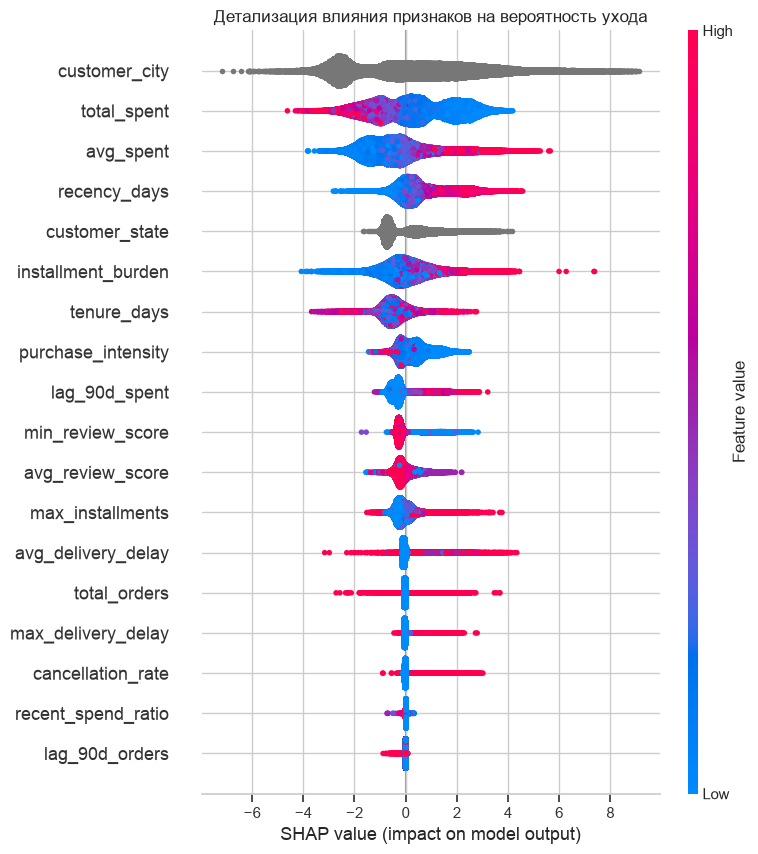

In [104]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)
shap_vals_to_plot = shap_values[1] if isinstance(shap_values, list) else shap_values


plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_to_plot, X_test, plot_type="bar", show=False)
plt.title('Топ факторов оттока (Глобальная важность)')
plt.tight_layout()
plt.savefig('Топ факторов оттока.png', dpi=300, bbox_inches='tight')
plt.show()


plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_to_plot, X_test, show=False)
plt.title('Детализация влияния признаков на вероятность ухода')
plt.tight_layout()
plt.savefig('Детализация влияния признаков на вероятность ухода.png', dpi=300, bbox_inches='tight')
plt.show()

In [100]:
error_df = X_test.copy()
error_df['y_true'] = y_test
error_df['pred_proba'] = final_preds_proba


error_df['y_pred'] = (error_df['pred_proba'] >= best_threshold).astype(int)
fp_df = error_df[(error_df['y_true'] == 0) & (error_df['y_pred'] == 1)]

print(f"Всего клиентов в тестовой выборке: {len(X_test)}")
print(f"Ошибочно предсказанный отток (False Positives): {len(fp_df)}\n")

features_to_check = ['total_spent', 'installment_burden', 'recency_days', 'purchase_intensity', 'avg_review_score']

print("Средние показатели клиентов (False Positives) vs (Вся выборка):")
comparison = pd.DataFrame({
    'Ложные срабатывания (FP)': fp_df[features_to_check].mean(),
    'Вся тестовая база': X_test[features_to_check].mean()
})
print(comparison.round(2))

Всего клиентов в тестовой выборке: 161556
Ошибочно предсказанный отток (False Positives): 719

Средние показатели клиентов (False Positives) vs (Вся выборка):
                    Ложные срабатывания (FP)  Вся тестовая база
total_spent                           164.56             165.92
installment_burden                     79.38                inf
recency_days                          160.42             203.70
purchase_intensity                      1.05               0.52
avg_review_score                        4.23               4.06


In [101]:
fn_df = error_df[(error_df['y_true'] == 1) & (error_df['y_pred'] == 0)]

print(f"Пропущенный отток (False Negatives): {len(fn_df)}\n")
print("Средние показатели: Пропущенный отток (FN) vs Вся база:")
comparison_fn = pd.DataFrame({
    'Пропущенный отток (FN)': fn_df[features_to_check].mean(),
    'Вся тестовая база': X_test[features_to_check].mean()
})
print(comparison_fn.round(2))

Пропущенный отток (False Negatives): 5

Средние показатели: Пропущенный отток (FN) vs Вся база:
                    Пропущенный отток (FN)  Вся тестовая база
total_spent                         129.06             165.92
installment_burden                   67.21                inf
recency_days                        264.20             203.70
purchase_intensity                    0.20               0.52
avg_review_score                      5.00               4.06


In [110]:
import joblib

categories_dict = {
    'customer_state': X_train['customer_state'].cat.categories,
    'customer_city': X_train['customer_city'].cat.categories
}
joblib.dump(categories_dict, 'categories_dict.pkl')


['categories_dict.pkl']